# 🌫️ Pearls AQI Predictor — Model Notebook

**Project:** End-to-End AQI Forecasting for Lahore,Punjab, Pakistan  
**Stack:** Open-Meteo API → Feature Engineering → Multi-Model Training → SHAP Explainability → Flask Dashboard

---

## 📁 Project Structure

```
Pearls-AQI-Predictor/
│
├── notebooks/                  ← 📓 THIS FILE (exploration & model experiments)
│   └── model.ipynb
│
├── aqi/                        ← 🚀 Production pipeline & dashboard
│   ├── pipeline.py             ← Main ML pipeline (runs everything end-to-end)
│   ├── app.py                  ← Flask web server (serves dashboard + API)
│   └── frontend.html           ← Dashboard UI (HTML/CSS/JS + Chart.js)
│
├── src/                        ← 🧠 Core library (importable modules)
│   ├── config.py               ← Central config (paths, columns, constants)
│   ├── alerts.py               ← AQI hazard alert logic
│   ├── features/               ← Feature engineering
│   │   ├── engineering.py      ← compute_features(), pm25_to_aqi etc.
│   │   └── fetch_raw.py        ← Open-Meteo API fetchers
│   ├── training/
│   │   └── train.py            ← Multi-model trainer (RF + Ridge + TF)
│   └── inference/
│       └── predict.py          ← Loads best model, runs 72h forecast
│
├── pipelines/                  ← ⚙️ CLI entry points for CI/CD
│   ├── feature_pipeline.py     ← python pipelines/feature_pipeline.py [--upload]
│   └── training_pipeline.py    ← python pipelines/training_pipeline.py [--register]
│
├── app/                        ← 📊 Alternative frontends
│   ├── streamlit_app.py        ← Streamlit dashboard (python -m streamlit run)
│   └── flask_api.py            ← Standalone Flask REST API
│
├── data/                       ← 📂 All data files (git-ignored large CSVs)
│   ├── lahore_aqi_historical_2024_onwards.csv   ← Training data
│   ├── aqi_dashboard_data.json                  ← Generated by pipeline.py
│   └── lahore_aqi_3day_forecast.csv             ← Generated by pipeline.py
│
├── models/                     ← 🤖 Saved model artifacts (git-ignored)
│   ├── best_model.pkl          ← Best sklearn model (RF or Ridge)
│   ├── best_model.keras        ← Best TF model (if TF wins)
│   ├── scaler.pkl              ← Fitted StandardScaler + feature names
│   └── training_results.json   ← Metrics for all trained models
│
├── .github/workflows/          ← 🔄 GitHub Actions CI/CD
│   ├── feature_pipeline.yml    ← Runs hourly: fetches + stores features
│   └── training_pipeline.yml   ← Runs daily: retrains + registers model
│
├── requirements.txt            ← Python dependencies
├── .env                        ← API keys (HOPSWORKS_API_KEY etc.) — never commit!
└── .env.example                ← Template for .env
```

## 🔧 Setup & Imports

In [2]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable
  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.66.0-cp313-cp313-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.48.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached llvmlite-0.48.0-cp313-cp313-win_amd64.whl (41.9 MB)
Using cached numba-0.66.0-cp313-cp313-win_amd64.whl (2.8 MB)

   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: C:\Users\Rana Zain Waseem\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests
import shap

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## 📥 1. Load Historical Data

In [5]:
DATA_PATH = '../data/lahore_aqi_historical_2024_onwards.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print(f'Rows: {len(df):,}')
print(f'Date range: {df["timestamp"].min().date()} → {df["timestamp"].max().date()}')
print(f'Columns: {list(df.columns)}')
df.head()

Rows: 22,656
Date range: 2024-01-01 → 2026-08-01
Columns: ['timestamp', 'temperature', 'humidity', 'wind_speed', 'pressure', 'modeled_pm25', 'modeled_pm10', 'ground_pm25', 'hour', 'day_of_week', 'month', 'aqi_change_rate', 'pm25_lag_1', 'pm25_lag_24', 'calculated_aqi', 'calculated_aqi_modeled']


,timestamp,temperature,humidity,wind_speed,pressure,modeled_pm25,modeled_pm10,ground_pm25,hour,day_of_week,month,aqi_change_rate,pm25_lag_1,pm25_lag_24,calculated_aqi,calculated_aqi_modeled
0,2024-01-01 00:00:00,6.3,98,2.8,992.3,155.1,222.6,141.436667,0,0,1,0.000000,NaN,NaN,195.0,206
1,2024-01-01 01:00:00,7.0,99,3.6,993.0,151.8,218.4,128.845000,1,0,1,-12.591667,141.436667,NaN,189.0,202
2,2024-01-01 02:00:00,7.2,98,3.2,993.5,153.7,220.7,131.483333,2,0,1,2.638333,128.845000,NaN,190.0,204
3,2024-01-01 03:00:00,7.9,99,2.8,994.2,156.0,224.4,140.615000,3,0,1,9.131667,131.483333,NaN,195.0,206
4,2024-01-01 04:00:00,9.2,98,2.8,994.7,159.3,228.6,142.643333,4,0,1,2.028333,140.615000,NaN,196.0,210


## 📊 2. Exploratory Data Analysis (EDA)

In [6]:
# --- Missing values ---
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Missing values per column:')
print(missing)

Missing values per column:
ground_pm25       9415
pm25_lag_1        9416
pm25_lag_24       9439
calculated_aqi     120
dtype: int64


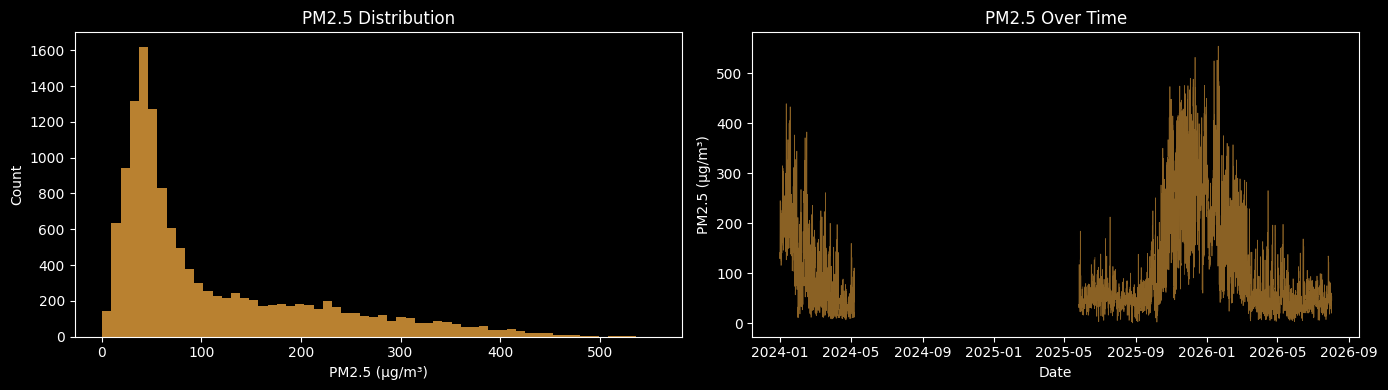

In [7]:
# --- PM2.5 distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['ground_pm25'].dropna(), bins=60, color=AMBER, alpha=0.8, edgecolor='none')
axes[0].set_title('PM2.5 Distribution', color='white')
axes[0].set_xlabel('PM2.5 (μg/m³)')
axes[0].set_ylabel('Count')

axes[1].plot(df['timestamp'], df['ground_pm25'], color=AMBER, alpha=0.6, linewidth=0.5)
axes[1].set_title('PM2.5 Over Time', color='white')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('PM2.5 (μg/m³)')

plt.tight_layout()
plt.show()

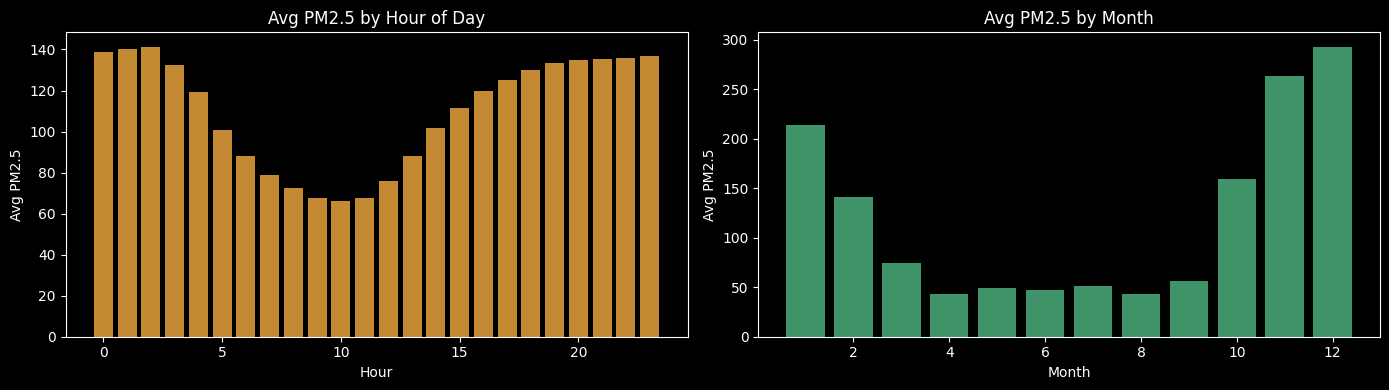

In [8]:
# --- Hourly and monthly seasonality ---
df['hour']  = df['timestamp'].dt.hour
df['month'] = df['timestamp'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hourly_avg = df.groupby('hour')['ground_pm25'].mean()
axes[0].bar(hourly_avg.index, hourly_avg.values, color=AMBER, alpha=0.85)
axes[0].set_title('Avg PM2.5 by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg PM2.5')

monthly_avg = df.groupby('month')['ground_pm25'].mean()
axes[1].bar(monthly_avg.index, monthly_avg.values, color=GREEN, alpha=0.85)
axes[1].set_title('Avg PM2.5 by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg PM2.5')

plt.tight_layout()
plt.show()

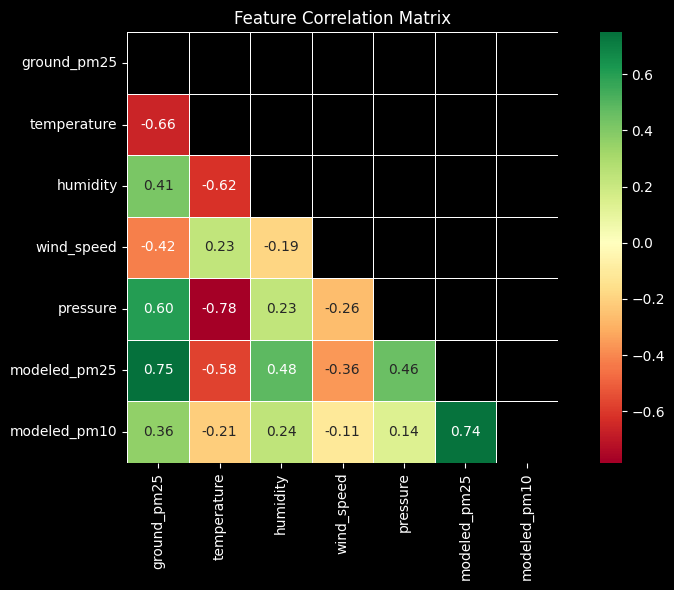

In [9]:
# --- Correlation heatmap ---
corr_cols = ['ground_pm25', 'temperature', 'humidity', 'wind_speed', 'pressure', 'modeled_pm25', 'modeled_pm10']
corr_cols = [c for c in corr_cols if c in df.columns]

plt.figure(figsize=(9, 6))
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## ⚙️ 3. Feature Engineering

In [10]:
def engineer_features(df):
    df = df.copy()
    df['month_sin']       = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']       = np.cos(2 * np.pi * df['month'] / 12)
    df['hour_sin']        = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']        = np.cos(2 * np.pi * df['hour'] / 24)
    df['day_of_week']     = df['timestamp'].dt.dayofweek
    df['pm25_lag_1']      = df['ground_pm25'].shift(1)
    df['pm25_lag_24']     = df['ground_pm25'].shift(24)
    df['pm25_roll_mean_3'] = df['ground_pm25'].rolling(3).mean().shift(1)
    df['pm25_roll_mean_6'] = df['ground_pm25'].rolling(6).mean().shift(1)
    return df

FEATURE_COLS = [
    'temperature', 'humidity', 'wind_speed', 'pressure',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_of_week',
    'pm25_lag_1', 'pm25_lag_24', 'pm25_roll_mean_3', 'pm25_roll_mean_6',
]
TARGET = 'ground_pm25'

df = engineer_features(df)
df_clean = df.dropna(subset=FEATURE_COLS + [TARGET]).reset_index(drop=True)
print(f'Usable rows after feature engineering: {len(df_clean):,}')
df_clean[FEATURE_COLS].describe().round(2)

Usable rows after feature engineering: 12,684


,temperature,humidity,wind_speed,pressure,hour_sin,hour_cos,month_sin,month_cos,day_of_week,pm25_lag_1,pm25_lag_24,pm25_roll_mean_3,pm25_roll_mean_6
count,12684.00,12684.00,12684.00,12684.00,12684.00,12684.00,12684.00,12684.00,12684.00,12684.00,12684.00,12684.00,12684.00
mean,23.54,64.65,6.38,983.56,-0.01,0.01,0.15,-0.08,3.01,110.27,110.75,110.16,109.91
std,8.97,23.06,3.94,7.16,0.71,0.71,0.69,0.71,1.99,102.18,102.48,100.84,98.42
min,2.70,9.00,0.00,967.20,-1.00,-1.00,-1.00,-1.00,0.00,0.38,0.38,1.46,3.73
25%,16.60,47.00,3.60,977.30,-0.71,-0.71,-0.50,-0.87,1.00,39.13,39.25,39.46,40.25
50%,25.20,68.00,5.60,983.80,0.00,0.00,0.50,-0.00,3.00,63.20,63.58,63.55,63.63
75%,30.20,84.00,8.50,989.80,0.71,0.71,0.87,0.50,5.00,159.03,159.65,159.75,161.54
max,46.10,100.00,35.00,1001.70,1.00,1.00,1.00,1.00,6.00,554.50,554.50,536.93,508.84


## 🤖 4. Multi-Model Training & Evaluation

In [11]:
X = df_clean[FEATURE_COLS]
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train size: {len(X_train):,} | Test size: {len(X_test):,}')

Train size: 10,147 | Test size: 2,537


In [12]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    rmse = float(np.sqrt(mean_squared_error(y_te, preds)))
    mae  = float(mean_absolute_error(y_te, preds))
    r2   = float(r2_score(y_te, preds))
    print(f'{name:30s}  RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.4f}')
    return {'model': model, 'name': name, 'rmse': rmse, 'mae': mae, 'r2': r2, 'preds': preds}

results = {}

results['rf'] = evaluate(
    'Random Forest',
    RandomForestRegressor(n_estimators=200, max_depth=16, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test
)

results['ridge'] = evaluate(
    'Ridge Regression',
    Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))]),
    X_train, y_train, X_test, y_test
)

try:
    import tensorflow as tf
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)
    tf_model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)
    ])
    tf_model.compile(optimizer='adam', loss='mse')
    tf_model.fit(X_tr_sc, y_train, epochs=20, batch_size=32, verbose=0)
    tf_preds = tf_model.predict(X_te_sc, verbose=0).flatten()
    rmse = float(np.sqrt(mean_squared_error(y_test, tf_preds)))
    mae  = float(mean_absolute_error(y_test, tf_preds))
    r2   = float(r2_score(y_test, tf_preds))
    print(f'{"TensorFlow Neural Network":30s}  RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.4f}')
    results['tf'] = {'name': 'TensorFlow NN', 'rmse': rmse, 'mae': mae, 'r2': r2, 'preds': tf_preds}
except ImportError:
    print('TensorFlow not installed — skipping.')

# Pick winner
best_key = min(results, key=lambda k: results[k]['rmse'])
best = results[best_key]
print(f'\n🏆 Best model: {best["name"]}  (RMSE={best["rmse"]:.3f})')

Random Forest                   RMSE=15.778  MAE=9.762  R²=0.9745
Ridge Regression                RMSE=16.749  MAE=10.806  R²=0.9712
TensorFlow not installed — skipping.

🏆 Best model: Random Forest  (RMSE=15.778)


## 📈 5. Residual Analysis

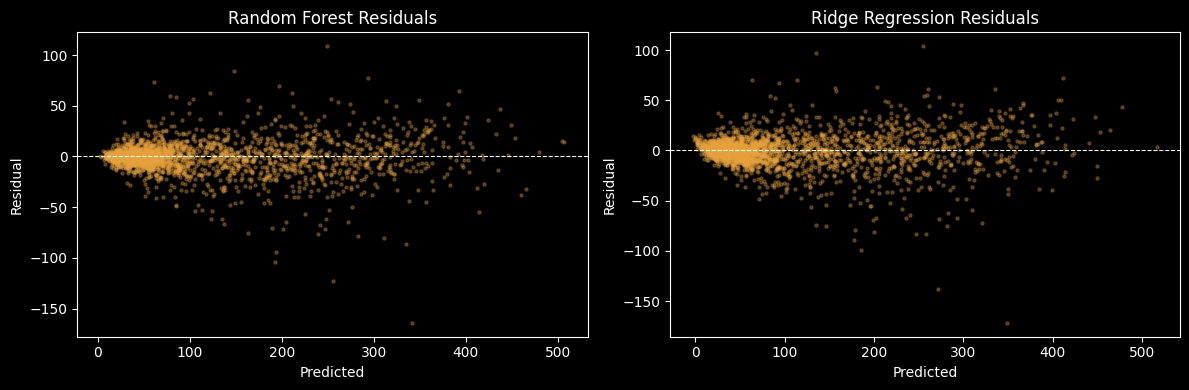

In [13]:
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 4))
if len(results) == 1: axes = [axes]

for ax, (key, r) in zip(axes, results.items()):
    residuals = np.array(y_test) - r['preds']
    ax.scatter(r['preds'], residuals, alpha=0.3, s=5, color=AMBER)
    ax.axhline(0, color='white', linewidth=0.8, linestyle='--')
    ax.set_title(f"{r['name']} Residuals")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual')

plt.tight_layout()
plt.show()

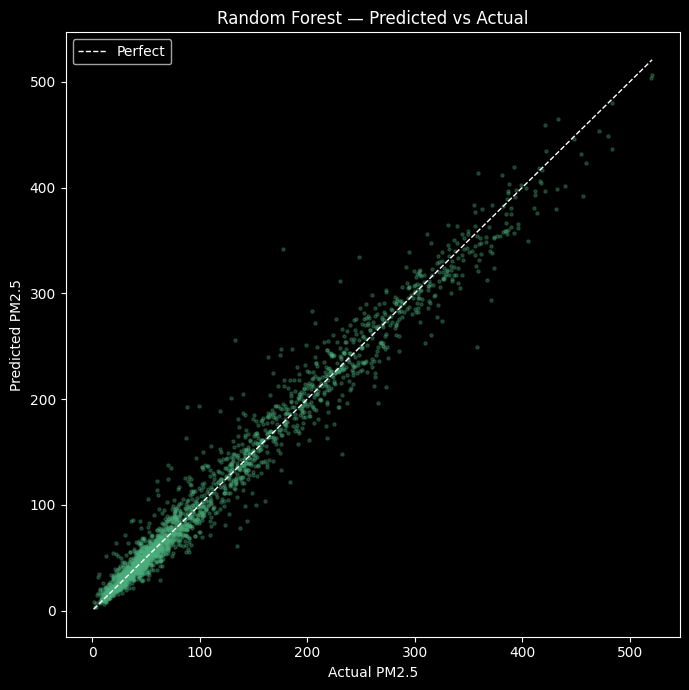

In [14]:
# Predicted vs Actual for the best model
best_preds = best['preds']
y_test_arr = np.array(y_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test_arr, best_preds, alpha=0.3, s=5, color=GREEN)
mn = min(y_test_arr.min(), best_preds.min())
mx = max(y_test_arr.max(), best_preds.max())
plt.plot([mn, mx], [mn, mx], color='white', linewidth=1, linestyle='--', label='Perfect')
plt.title(f'{best["name"]} — Predicted vs Actual')
plt.xlabel('Actual PM2.5')
plt.ylabel('Predicted PM2.5')
plt.legend()
plt.tight_layout()
plt.show()

## 🔍 6. SHAP Feature Importance (Best Model)

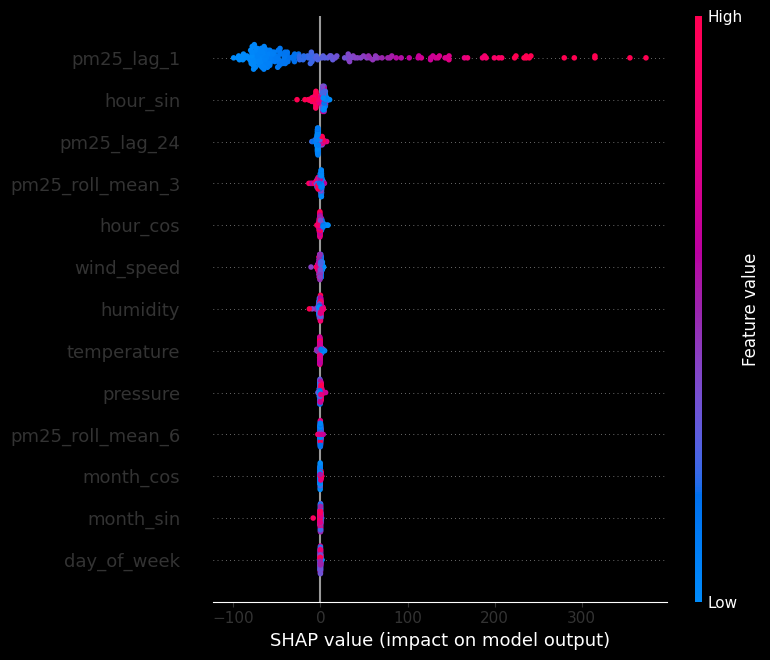

In [15]:
# Only run SHAP for sklearn models in this notebook
best_sklearn = results.get('rf') if results.get('rf') else results.get('ridge')
if best_sklearn:
    sk_model = best_sklearn['model']
    if isinstance(sk_model, Pipeline):
        raw_model = sk_model.named_steps['ridge']
        X_scaled = sk_model.named_steps['scaler'].transform(X_test)
        X_shap = pd.DataFrame(X_scaled, columns=FEATURE_COLS)
        explainer = shap.LinearExplainer(raw_model, X_shap)
    else:
        X_shap = X_test
        explainer = shap.TreeExplainer(sk_model)

    shap_values = explainer.shap_values(X_shap.iloc[:200])
    shap.summary_plot(shap_values, X_shap.iloc[:200], feature_names=FEATURE_COLS, show=True)

## 🔄 7. How to Run the Full Production Pipeline

All the steps above are automated in `aqi/pipeline.py`. Here's how to use the project end-to-end:

### Step 1 — Activate your virtual environment
```bash
myvenv\Scripts\activate   # Windows
source myvenv/bin/activate # Linux / Mac
```

### Step 2 — Run the ML pipeline (fetches live data, trains models, exports JSON)
```bash
python aqi/pipeline.py
```

### Step 3 — Start the Flask dashboard
```bash
python aqi/app.py
# Open http://127.0.0.1:5000
```

### Alternative — Run the Streamlit dashboard
```bash
streamlit run app/streamlit_app.py
```

### Alternative — Run the full src training pipeline (with Hopsworks)
```bash
python -m src.training.train
python -m src.training.train --register   # to push to Hopsworks Model Registry
```

### CI/CD — GitHub Actions runs automatically:
- **Every hour:** `.github/workflows/feature_pipeline.yml` → fetches new data
- **Every day:** `.github/workflows/training_pipeline.yml` → retrains model

## 📋 8. Model Metrics Summary

In [16]:
metrics_df = pd.DataFrame([
    {'Model': r['name'], 'RMSE': round(r['rmse'], 3), 'MAE': round(r['mae'], 3), 'R²': round(r['r2'], 4)}
    for r in results.values()
]).sort_values('RMSE')
metrics_df['Best'] = metrics_df['RMSE'] == metrics_df['RMSE'].min()
display(metrics_df.style
        .apply(lambda row: ['background-color: #1e3a2f' if row['Best'] else '' for _ in row], axis=1)
        .format({'RMSE': '{:.3f}', 'MAE': '{:.3f}', 'R²': '{:.4f}'})
        .hide(axis='columns', subset=['Best']))

,Model,RMSE,MAE,R²
0,Random Forest,15.778,9.762,0.9745
1,Ridge Regression,16.749,10.806,0.9712
